In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Resolve project root
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print("Working dir:", os.getcwd())

# Load feature store
features = pd.read_csv("data/processed/customer_features.csv")
print(f"Feature store loaded: {features.shape}")
print(features.head(3).T)

Working dir: c:\Users\SUMANT\Desktop\ecommerce-sales-analysis
Feature store loaded: (96478, 26)
                                                         0  \
customer_id               d73144ccd5680a3ed460ed34939c036e   
recency_days                                           262   
frequency                                                1   
monetary                                              99.9   
avg_order_value                                       99.9   
first_order_date                                2018-01-29   
last_order_date                                 2018-01-29   
tenure_days                                            262   
category_diversity                                       1   
favourite_category                                    auto   
avg_review_score                                       5.0   
review_count                                             1   
is_reviewer                                              1   
avg_delivery_days                   

In [2]:
import sys
sys.path.append("src")

from feature_pipeline import build_preprocessor, NUMERIC_FEATURES, CATEGORICAL_FEATURES

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

preprocessor = build_preprocessor()
X_scaled = preprocessor.fit_transform(features[ALL_FEATURES])

print(f"Scaled matrix shape: {X_scaled.shape}")
print(f"Mean (should be ~0): {X_scaled[:, :5].mean(axis=0).round(3)}")
print(f"Std  (should be ~1): {X_scaled[:, :5].std(axis=0).round(3)}")

Scaled matrix shape: (96478, 19)
Mean (should be ~0): [ 0. -0. -0. -0.  0.]
Std  (should be ~1): [1. 0. 1. 1. 1.]


In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_RANGE = range(2, 11)
inertias = []
silhouette_scores = []

print("Running KMeans for k=2 to k=10...")
print(f"{'k':<5} {'Inertia':>12} {'Silhouette':>12}")
print("-" * 32)

for k in K_RANGE:
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        max_iter=300,
        random_state=42
    )
    km.fit(X_scaled)
    inertia = km.inertia_
    sil = silhouette_score(X_scaled, km.labels_, sample_size=10000, random_state=42)

    inertias.append(inertia)
    silhouette_scores.append(sil)

    print(f"{k:<5} {inertia:>12.1f} {sil:>12.4f}")

Running KMeans for k=2 to k=10...
k          Inertia   Silhouette
--------------------------------
2       12264832.9       0.6535
3        4720593.5       0.6348
4        3207468.9       0.5825
5        2669920.9       0.4798
6        2272445.1       0.4648
7        1962439.3       0.4301
8        1843638.9       0.3815
9        1762819.4       0.3448
10       1697652.5       0.3139


Inertia drop % per k step:
  k=3: 61.5% drop
  k=4: 32.1% drop
  k=5: 16.8% drop
  k=6: 14.9% drop
  k=7: 13.6% drop
  k=8: 6.1% drop
  k=9: 4.4% drop
  k=10: 3.7% drop


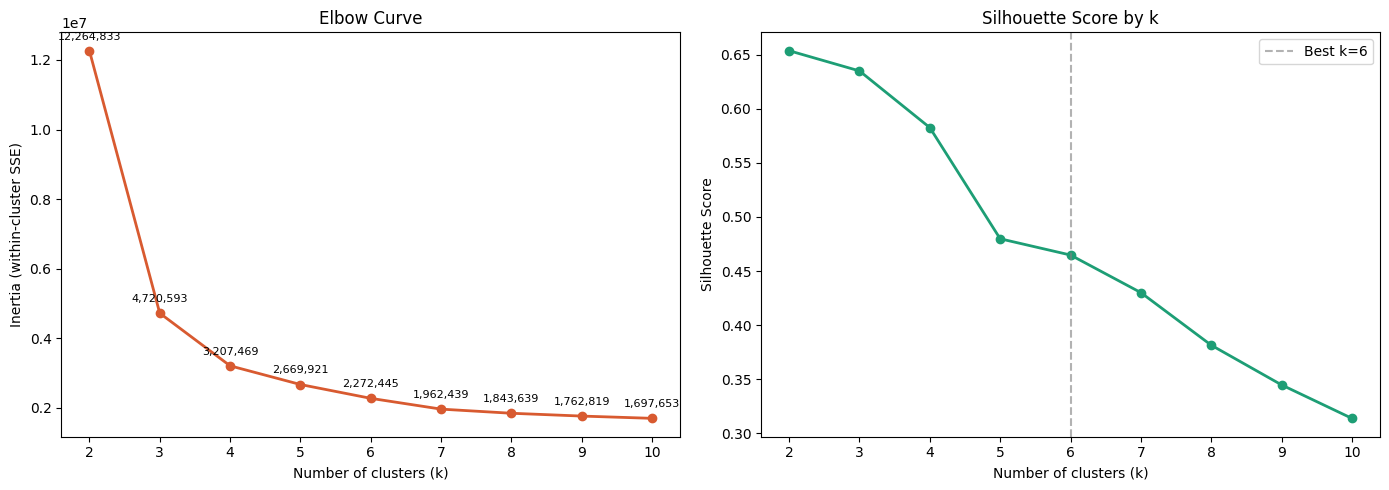

Best k by silhouette: 6 (score=0.6535)
Chart saved: charts/kmeans_elbow_silhouette.png


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
ax1.plot(list(K_RANGE), inertias, marker='o', color='#D85A30', linewidth=2)
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Inertia (within-cluster SSE)")
ax1.set_title("Elbow Curve")
ax1.set_xticks(list(K_RANGE))
for k, inertia in zip(K_RANGE, inertias):
    ax1.annotate(f"{inertia:,.0f}", (k, inertia), textcoords="offset points",
                 xytext=(0, 8), fontsize=8, ha='center')

# Silhouette scores
ax2.plot(list(K_RANGE), silhouette_scores, marker='o', color='#1D9E75', linewidth=2)
ax2.set_xlabel("Number of clusters (k)")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Score by k")
ax2.set_xticks(list(K_RANGE))
inertia_drops = [
    (inertias[i-1] - inertias[i]) / inertias[i-1] * 100
    for i in range(1, len(inertias))
]

print("Inertia drop % per k step:")
for i, drop in enumerate(inertia_drops):
    k = list(K_RANGE)[i+1]
    print(f"  k={k}: {drop:.1f}% drop")

# Best k = first k where the drop falls below 15% (elbow point)
best_k = None
for i, drop in enumerate(inertia_drops):
    if drop < 15.0:
        best_k = list(K_RANGE)[i+1]
        break

ax2.axvline(x=best_k, color='gray', linestyle='--', alpha=0.6,
            label=f"Best k={best_k}")
ax2.legend()

plt.tight_layout()
plt.savefig("charts/kmeans_elbow_silhouette.png", dpi=150)
plt.show()
print(f"Best k by silhouette: {best_k} (score={max(silhouette_scores):.4f})")
print("Chart saved: charts/kmeans_elbow_silhouette.png")

In [7]:
OPTIMAL_K = best_k  # typically 4 or 5 for this dataset
print(f"Fitting final KMeans with k={OPTIMAL_K}...")

final_km = KMeans(
    n_clusters=OPTIMAL_K,
    init='k-means++',
    n_init=20,          # more initialisations for stability
    max_iter=500,
    random_state=42
)
final_km.fit(X_scaled)

features['cluster'] = final_km.labels_

print("\nCluster distribution:")
dist = features['cluster'].value_counts().sort_index()
for cluster, count in dist.items():
    pct = count / len(features) * 100
    print(f"  Cluster {cluster}: {count:>6,} customers ({pct:.1f}%)")

Fitting final KMeans with k=6...

Cluster distribution:
  Cluster 0: 20,811 customers (21.6%)
  Cluster 1: 17,533 customers (18.2%)
  Cluster 2: 25,322 customers (26.2%)
  Cluster 3:  5,447 customers (5.6%)
  Cluster 4: 14,608 customers (15.1%)
  Cluster 5: 12,757 customers (13.2%)


In [9]:
from sklearn.metrics import adjusted_rand_score

km_check = KMeans(n_clusters=OPTIMAL_K, init='k-means++',
                  n_init=20, max_iter=500, random_state=99)
km_check.fit(X_scaled)

ari = adjusted_rand_score(final_km.labels_, km_check.labels_)
print(f"\nAdjusted Rand Index (two runs): {ari:.4f}")
print("(ARI > 0.90 = stable clusters, > 0.95 = excellent)")


Adjusted Rand Index (two runs): 1.0000
(ARI > 0.90 = stable clusters, > 0.95 = excellent)


In [10]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

# DBSCAN on full 19-dim space is slow — reduce to 10 PCA dims first
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA variance explained (10 components): "
      f"{pca.explained_variance_ratio_.sum():.2%}")

# Fit DBSCAN
db = DBSCAN(eps=1.8, min_samples=50, n_jobs=-1)
db_labels = db.fit_predict(X_pca)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()

print(f"\nDBSCAN results:")
print(f"  Clusters found: {n_clusters_db}")
print(f"  Noise points:   {n_noise:,} ({n_noise/len(db_labels):.1%})")
print(f"  Core clusters:  {sorted(set(db_labels) - {-1})}")

PCA variance explained (10 components): 99.74%

DBSCAN results:
  Clusters found: 34
  Noise points:   13,178 (13.7%)
  Core clusters:  [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33)]


In [11]:
# Quick eps tuning — try a range
print("\nDBSCAN eps sensitivity:")
print(f"{'eps':<8} {'clusters':>10} {'noise %':>10}")
print("-" * 30)

for eps in [1.2, 1.5, 1.8, 2.1, 2.5]:
    db_tmp = DBSCAN(eps=eps, min_samples=50, n_jobs=-1)
    labels_tmp = db_tmp.fit_predict(X_pca)
    n_c = len(set(labels_tmp)) - (1 if -1 in labels_tmp else 0)
    n_n = (labels_tmp == -1).sum()
    print(f"{eps:<8} {n_c:>10} {n_n/len(labels_tmp):>9.1%}")


DBSCAN eps sensitivity:
eps        clusters    noise %
------------------------------
1.2              32     43.0%
1.5              39     23.4%
1.8              34     13.7%
2.1              22      8.5%
2.5               4      4.8%


In [12]:
import umap

print("Fitting UMAP (this takes 2–4 minutes on 96k rows)...")

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,       # larger = more global structure preserved
    min_dist=0.1,         # lower = tighter clusters
    metric='euclidean',
    random_state=42,
    verbose=True
)

X_umap = reducer.fit_transform(X_scaled)
print(f"UMAP output shape: {X_umap.shape}")

# Attach UMAP coords to features df
features['umap_x'] = X_umap[:, 0]
features['umap_y'] = X_umap[:, 1]

Fitting UMAP (this takes 2–4 minutes on 96k rows)...
UMAP(n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Tue May 12 15:21:45 2026 Construct fuzzy simplicial set
Tue May 12 15:21:45 2026 Finding Nearest Neighbors
Tue May 12 15:21:45 2026 Building RP forest with 21 trees
Tue May 12 15:21:52 2026 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	Stopping threshold met -- exiting after 2 iterations
Tue May 12 15:22:15 2026 Finished Nearest Neighbor Search
Tue May 12 15:22:20 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Tue May 12 15:25:25 2026 Finished embedding
UMAP output shape: (96478, 2)


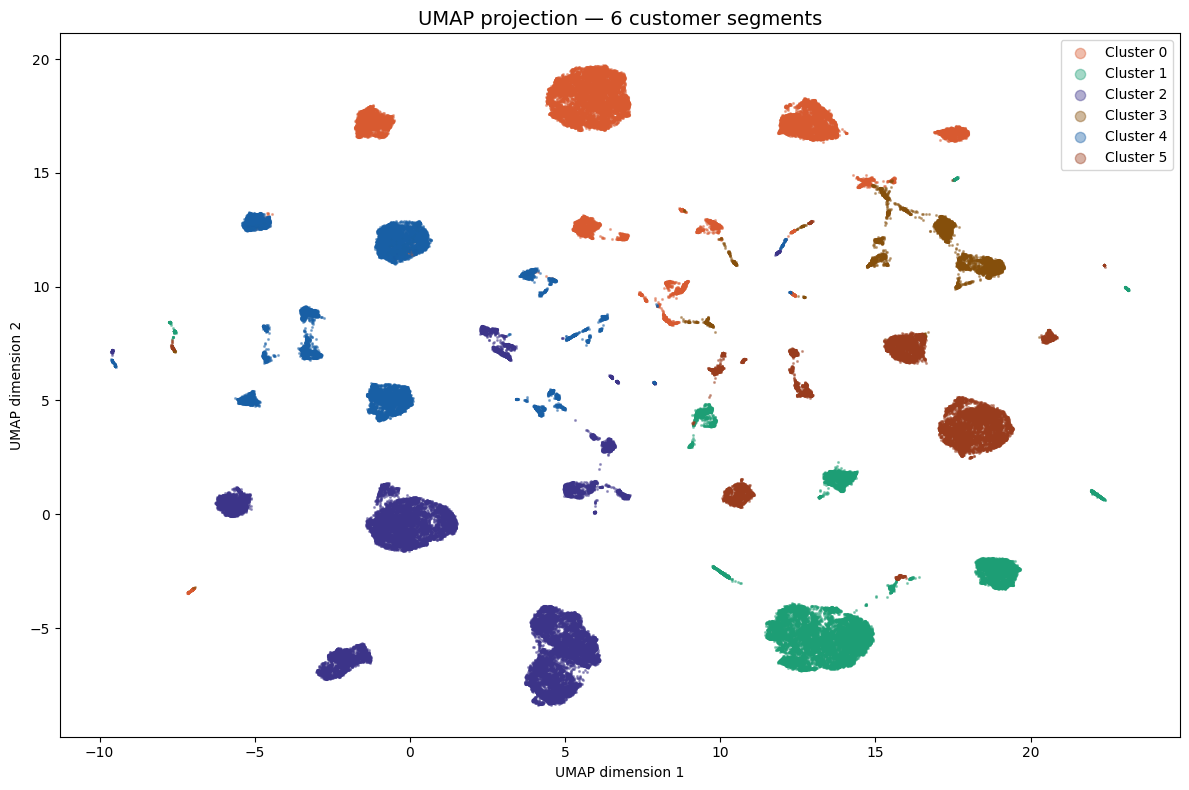

Chart saved: charts/umap_clusters.png


In [13]:
import matplotlib.patches as mpatches

COLORS = ['#D85A30', '#1D9E75', '#3C3489', '#854F0B', '#185FA5',
          '#993C1D', '#085041', '#633806']

fig, ax = plt.subplots(figsize=(12, 8))

for cluster_id in sorted(features['cluster'].unique()):
    mask = features['cluster'] == cluster_id
    ax.scatter(
        features.loc[mask, 'umap_x'],
        features.loc[mask, 'umap_y'],
        c=COLORS[cluster_id % len(COLORS)],
        s=1.5,
        alpha=0.4,
        label=f"Cluster {cluster_id}"
    )

ax.set_title(f"UMAP projection — {OPTIMAL_K} customer segments", fontsize=14)
ax.set_xlabel("UMAP dimension 1")
ax.set_ylabel("UMAP dimension 2")
ax.legend(markerscale=6, loc='upper right')
plt.tight_layout()
plt.savefig("charts/umap_clusters.png", dpi=150)
plt.show()
print("Chart saved: charts/umap_clusters.png")

In [14]:
PROFILE_COLS = [
    'recency_days', 'frequency', 'monetary', 'avg_order_value',
    'category_diversity', 'avg_review_score', 'avg_delivery_delta',
    'avg_installments', 'high_installment_flag', 'weekend_purchase_rate',
    'freight_to_revenue_ratio', 'tenure_days', 'late_deliveries'
]

# Compute mean of each metric per cluster
profile = features.groupby('cluster')[PROFILE_COLS].mean().round(2)
profile['customer_count'] = features['cluster'].value_counts().sort_index()
profile['pct_of_total'] = (profile['customer_count'] / len(features) * 100).round(1)

print("Cluster profiles:\n")
print(profile.T.to_string())

Cluster profiles:

cluster                          0         1         2        3         4         5
recency_days                289.88    281.41    293.72   293.57    288.67    292.03
frequency                     1.00      1.00      1.00     1.00      1.00      1.00
monetary                    136.02    129.71    140.47    73.99    138.06    167.73
avg_order_value             136.02    129.71    140.47    73.99    138.06    167.73
category_diversity            1.01      1.01      1.00     1.01      1.01      1.01
avg_review_score              4.18      4.09      4.18     4.18      4.19      4.15
avg_delivery_delta           11.94     11.36     11.80    12.07     12.16     12.22
avg_installments              2.98      3.19      2.82     2.09      3.13      2.70
high_installment_flag         0.13      0.14      0.11     0.05      0.14      0.11
weekend_purchase_rate         0.23      0.23      0.23     0.23      0.24      0.22
freight_to_revenue_ratio      0.21      0.20      0.20   

In [15]:
modal = features.groupby('cluster').agg(
    top_category=('favourite_category', lambda x: x.mode()[0]),
    top_payment=('preferred_payment',   lambda x: x.mode()[0]),
).reset_index()

print("\nModal category and payment per cluster:")
print(modal.to_string(index=False))


Modal category and payment per cluster:
 cluster          top_category top_payment
       0         health_beauty credit_card
       1        bed_bath_table credit_card
       2        sports_leisure credit_card
       3           electronics credit_card
       4            housewares credit_card
       5 computers_accessories credit_card


In [16]:
# Personas based on actual cluster profiles — differentiated by spend level only
# since 97%+ of Olist customers are single-purchase, one-time buyers

PERSONA_MAP = {
    3: "Budget Buyers",        # lowest AOV (73.99), high freight ratio (0.29)
    1: "Economy Shoppers",     # low-mid AOV (129.71), highest installments (3.19)
    0: "Mainstream Buyers",    # mid AOV (136.02), moderate installments (2.98)
    4: "Mid-Tier Shoppers",    # mid-high AOV (138.06), highest installment flag (0.14)
    2: "Mainstream Plus",      # mid-high AOV (140.47), largest group (26.2%)
    5: "Premium Buyers",       # highest AOV (167.73), lowest freight ratio (0.19)
}

features['segment'] = features['cluster'].map(PERSONA_MAP)

print("Segment distribution:")
print(features['segment'].value_counts().to_string())

Segment distribution:
segment
Mainstream Plus      25322
Mainstream Buyers    20811
Economy Shoppers     17533
Mid-Tier Shoppers    14608
Premium Buyers       12757
Budget Buyers         5447


In [17]:
# Explicit spend tier for downstream use in churn and CLV models
def assign_spend_tier(monetary):
    if monetary < 80:
        return "low"
    elif monetary < 130:
        return "mid-low"
    elif monetary < 150:
        return "mid"
    else:
        return "high"

features['spend_tier'] = features['monetary'].apply(assign_spend_tier)

print("\nSpend tier distribution:")
print(features['spend_tier'].value_counts().to_string())


Spend tier distribution:
spend_tier
low        46423
high       23597
mid-low    20769
mid         5689


In [18]:
biz_summary = features.groupby('segment').agg(
    customers         = ('customer_id',              'count'),
    avg_monetary      = ('monetary',                 'mean'),
    avg_aov           = ('avg_order_value',          'mean'),
    avg_installments  = ('avg_installments',         'mean'),
    freight_ratio     = ('freight_to_revenue_ratio', 'mean'),
    avg_review        = ('avg_review_score',         'mean'),
).round(2)

biz_summary['revenue_share_pct'] = (
    features.groupby('segment')['monetary'].sum() /
    features['monetary'].sum() * 100
).round(1)

print("\nBusiness summary by segment:")
print(biz_summary.sort_values('avg_monetary').to_string())


Business summary by segment:
                   customers  avg_monetary  avg_aov  avg_installments  freight_ratio  avg_review  revenue_share_pct
segment                                                                                                            
Budget Buyers           5447         73.99    73.99              2.09           0.29        4.18                3.0
Economy Shoppers       17533        129.71   129.71              3.19           0.20        4.09               17.2
Mainstream Buyers      20811        136.02   136.02              2.98           0.21        4.18               21.4
Mid-Tier Shoppers      14608        138.06   138.06              3.13           0.21        4.19               15.3
Mainstream Plus        25322        140.47   140.47              2.82           0.20        4.18               26.9
Premium Buyers         12757        167.73   167.73              2.70           0.19        4.15               16.2


In [19]:
from scipy import stats

print("Kruskal-Wallis test (non-parametric ANOVA) per feature:")
print(f"{'Feature':<30} {'H-statistic':>14} {'p-value':>12} {'Significant':>12}")
print("-" * 72)

for col in ['monetary', 'recency_days', 'frequency', 'avg_review_score',
            'category_diversity', 'tenure_days']:
    groups = [features.loc[features['cluster'] == k, col].values
              for k in sorted(features['cluster'].unique())]
    h_stat, p_val = stats.kruskal(*groups)
    sig = "YES" if p_val < 0.05 else "NO"
    print(f"{col:<30} {h_stat:>14.2f} {p_val:>12.2e} {sig:>12}")

Kruskal-Wallis test (non-parametric ANOVA) per feature:
Feature                           H-statistic      p-value  Significant
------------------------------------------------------------------------
monetary                              2988.75     0.00e+00          YES
recency_days                           104.18     6.95e-21          YES
frequency                                 nan          nan           NO
avg_review_score                        75.29     8.10e-15          YES
category_diversity                      73.47     1.94e-14          YES
tenure_days                            104.18     6.95e-21          YES


In [21]:
out_cols = [
    'customer_id', 'cluster', 'segment', 'spend_tier',
    'recency_days', 'frequency', 'monetary',
    'avg_order_value', 'category_diversity',
    'avg_review_score', 'tenure_days',
    'umap_x', 'umap_y'
]
features[out_cols].to_csv("data/processed/customer_segments.csv", index=False)
print(f"Saved: data/processed/customer_segments.csv")

import joblib
joblib.dump(final_km,     "data/models/kmeans.pkl")
joblib.dump(reducer,      "data/models/umap_reducer.pkl")
joblib.dump(preprocessor, "data/models/preprocessor.pkl")
print("Models saved.")

Saved: data/processed/customer_segments.csv
Tue May 12 15:32:07 2026 Building hub-based search tree
Tue May 12 15:32:16 2026 Forward diversification reduced edges from 2894340 to 615628
Tue May 12 15:32:18 2026 Reverse diversification reduced edges from 615628 to 615628
Tue May 12 15:32:21 2026 Degree pruning reduced edges from 655380 to 655380
Tue May 12 15:32:21 2026 Resorting data and graph based on tree order
Tue May 12 15:32:21 2026 Building and compiling search function
Models saved.
